## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [2]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function

OBJECT_NAME = "LAMP_HGNE"
EXPOSURE = 500000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name, exp_time=200):
    bias_folder = f"{object_name}/BIAS_{exp_time}"
    bias_files = sorted(os.listdir(bias_folder))
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)), dtype=np.float32)

    for i, bias in tqdm(enumerate(bias_files)): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data.astype(np.float32)

    master_bias = np.median(biases, axis=2)
    return master_bias

In [4]:
MASTER_BIAS = master_bias(OBJECT_NAME)

0it [00:00, ?it/s]

50it [00:01, 27.87it/s]


### Master bias visualisation

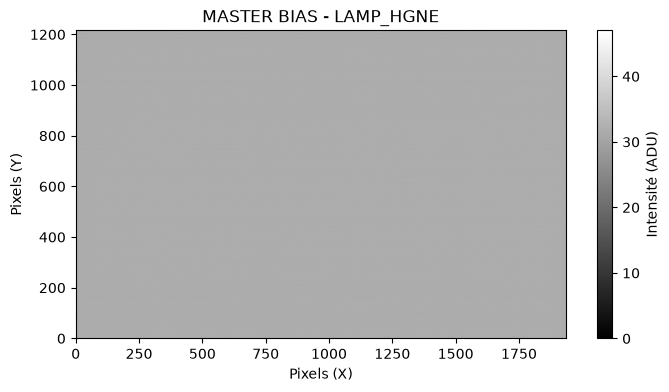

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER BIAS - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **3. Creating the master dark**

We will also remove the master bias from each of them, as to obtain as thermically pure master dark

### Function

s important pour la suite (La soustraction sur tes "Lights")

Puisque ton `master_dark` est maintenant "pur" (sans le bruit de lecture), l'équation de prétraitement pour tes images d'objets (*Light frames*) change.

Au lieu de faire simplement `Light - Master_Dark`, tu devras faire :


$$\text{Image Corrigée} = \text{Light} - \text{Master Bias} - \text{Master Dark}$$

Cette méthode est la plus rigoureuse car elle te permettra plus tard (si tu le souhaites) de "scaler" ton dark. Par exemple, si tu as un Master Dark de 60s mais une image d'objet de 30s, tu pourras faire : `Light - Master_Bias - (Master_Dark * 0.5)`. C'est ultra pratique en astronomie professionnelle ou pour de la recherche d'exoplanètes où les temps de pose varient !

In [6]:
def master_dark(object_name,exp_time, master_bias):
    dark_folder = f"TRUE_DARK_{exp_time}_1/DARK_{exp_time}"
    dark_files = sorted(os.listdir(dark_folder))
    darks = np.zeros((MAX_H,MAX_W,len(dark_files)), dtype=np.float32)

    for i, dark in tqdm(enumerate(dark_files)): # loop for each bias in the bias folder
        with fits.open(f"{dark_folder}/{dark}") as hdul: # open fits file
            darks[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    master_dark = np.median(darks, axis=2)
    return master_dark

In [7]:
MASTER_DARK = master_dark(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

50it [00:01, 25.43it/s]


### Master dark visualization

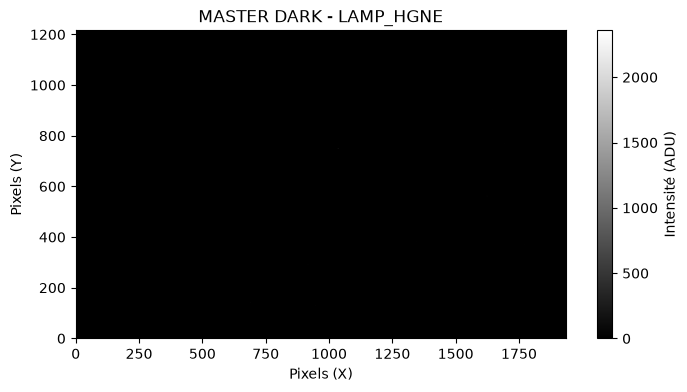

In [8]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_DARK, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER DARK - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **4. Creating the master flat**

Similarly to the master dark, we will substract the bias for each flat frame

### Function

In [9]:
def master_flat(object_name,exp_time, master_bias):
    flat_folder = f"TEST_FLAT/FLAT_{exp_time}"
    flat_files = sorted(os.listdir(flat_folder))
    flats = np.zeros((MAX_H,MAX_W,len(flat_files)), dtype=np.float32)

    for i, flat in tqdm(enumerate(flat_files)): # loop for each bias in the bias folder
        with fits.open(f"{flat_folder}/{flat}") as hdul: # open fits file
            flats[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    raw_master_flat = np.median(flats, axis=2)

    master_flat = raw_master_flat / np.median(raw_master_flat) # correct for the vignetting/dust without changing the actual value of each pixel
    return master_flat

In [10]:
MASTER_FLAT = master_flat(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

20it [00:00, 37.66it/s]


### Master flat visualization

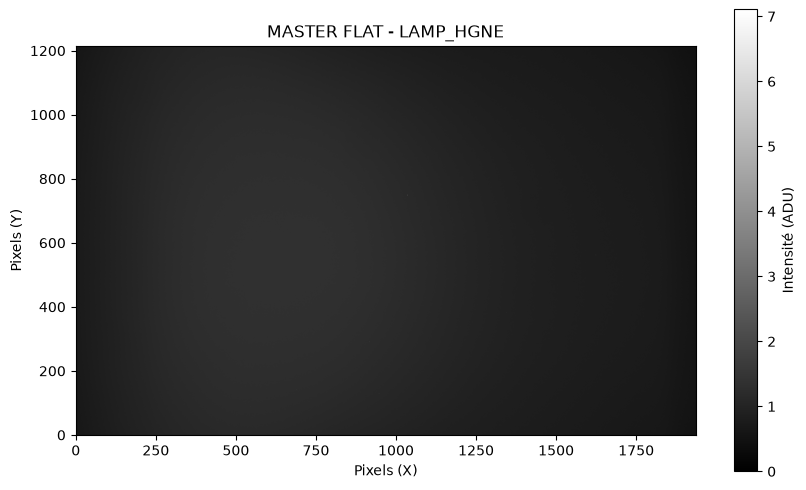

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER FLAT - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

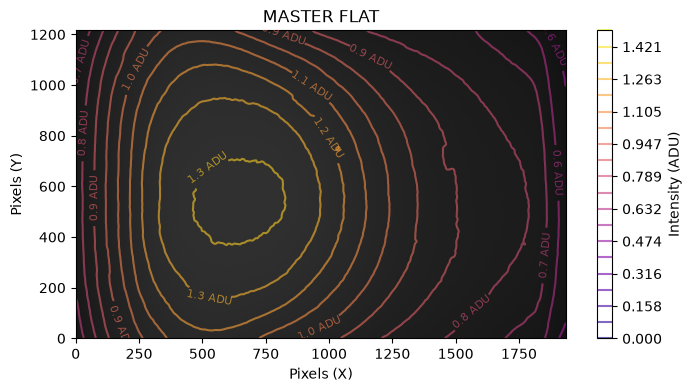

In [12]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

fig, ax = plt.subplots(figsize=(8,4))

# Astuce essentielle : on lisse légèrement l'image (sigma=3 ou 5) 
# UNIQUEMENT pour le calcul des contours, pour éviter le bruit pixel par pixel.
MASTER_FLAT_SMOOTHED = gaussian_filter(MASTER_FLAT, sigma=5)

# On définit des niveaux précis adaptés à ta dynamique (0 à 5 ADU)
# niveaux = [1.0, 2.0, 3.0, 4.0, 5.0]
niveaux = np.linspace(0, 1.5, 20)
im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# Tracé des contours
# cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)
cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)

# Ajout des étiquettes sur les lignes
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f ADU')

ax.set_title(f"MASTER FLAT")# - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(cs, ax=ax, label="Intensity (ADU)")

plt.show()

## **5. Creating the final corrected image**

### Function

In [13]:
def master_science(object_name, exp_time, m_bias, m_dark, m_flat):
    science_folder = f"{object_name}/SCIENCE_{exp_time}"
    science_files = sorted(os.listdir(science_folder))
    sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)

    for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
        with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
            sciences[:,:,i] = hdul[0].data.astype(np.float32) - m_bias.astype(np.float32) - m_dark.astype(np.float32)
            header = hdul[0].header

    master_science_uncorrected = np.median(sciences, axis=2)
    master_science = (np.median(sciences, axis=2)) / m_flat

    return master_science,master_science_uncorrected, header

In [14]:
MASTER_SCIENCE_NE_FIX, MASTER_SCIENCE_UNCORR_NE_FIX, header = master_science(OBJECT_NAME, 500000, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

50it [00:01, 25.67it/s]


In [15]:
MASTER_SCIENCE_HG_FIX, MASTER_SCIENCE_UNCORR_HG_FIX, header = master_science(OBJECT_NAME, 20000, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

50it [00:01, 26.06it/s]


In [16]:
split_col = 1000

MASTER_SCIENCE_NE = MASTER_SCIENCE_NE_FIX - 100
MASTER_SCIENCE_UNCORR_NE = MASTER_SCIENCE_UNCORR_NE_FIX - 100

MASTER_SCIENCE = np.hstack((
    MASTER_SCIENCE_NE[:, :split_col],
    MASTER_SCIENCE_HG_FIX[:, split_col:]
))

MASTER_SCIENCE_UNCORR = np.hstack((
    MASTER_SCIENCE_UNCORR_NE[:, :split_col],
    MASTER_SCIENCE_UNCORR_HG_FIX[:, split_col:]
))

neg_mask = MASTER_SCIENCE_UNCORR < 0
MASTER_SCIENCE_UNCORR[neg_mask] = 1#np.median(MASTER_SCIENCE_UNCORR[neg_mask])

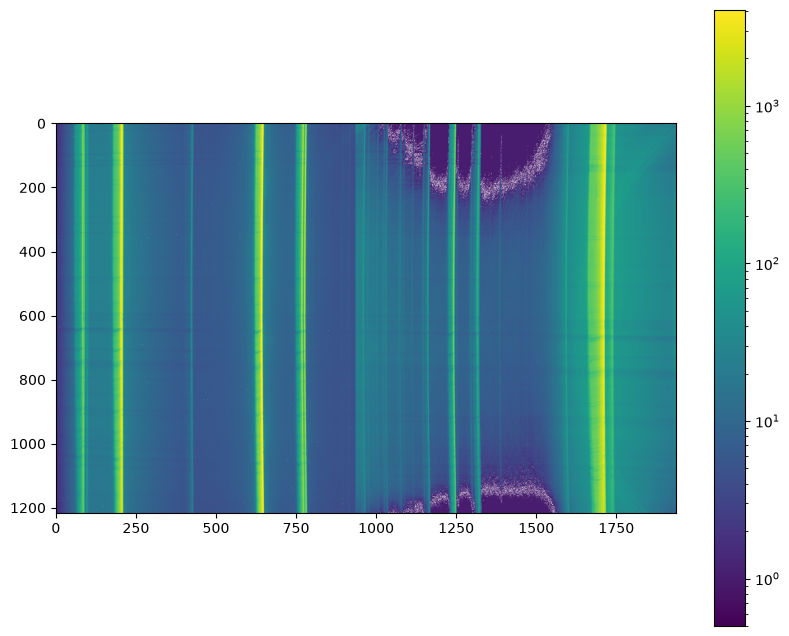

In [17]:
# %matplotlib qt
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(10,8))
plt.imshow(np.flip(MASTER_SCIENCE_UNCORR[:,:]),norm=LogNorm())
# plt.xlim(0,300)
# plt.xlim(655,MAX_W)
plt.colorbar()
plt.grid(False)

### Master science visualisation

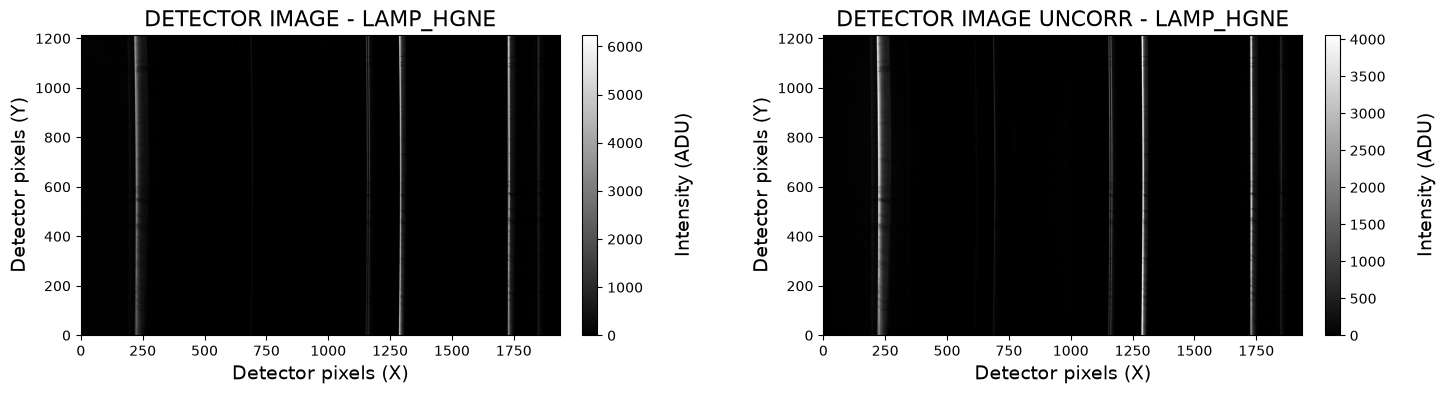

In [18]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,4))

im1 = ax1.imshow((MASTER_SCIENCE), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax1.set_title(f"DETECTOR IMAGE - {OBJECT_NAME}", fontsize=16)
ax1.set_xlabel("Detector pixels (X)", fontsize=14)
ax1.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar1 = fig.colorbar(im1, ax=ax1, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar1.set_label('\nIntensity (ADU)', fontsize=14)

im2 = ax2.imshow((MASTER_SCIENCE_UNCORR), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax2.set_title(f"DETECTOR IMAGE UNCORR - {OBJECT_NAME}", fontsize=16)
ax2.set_xlabel("Detector pixels (X)", fontsize=14)
ax2.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar2 = fig.colorbar(im2, ax=ax2, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar2.set_label('\nIntensity (ADU)', fontsize=14)

plt.tight_layout()
plt.show()

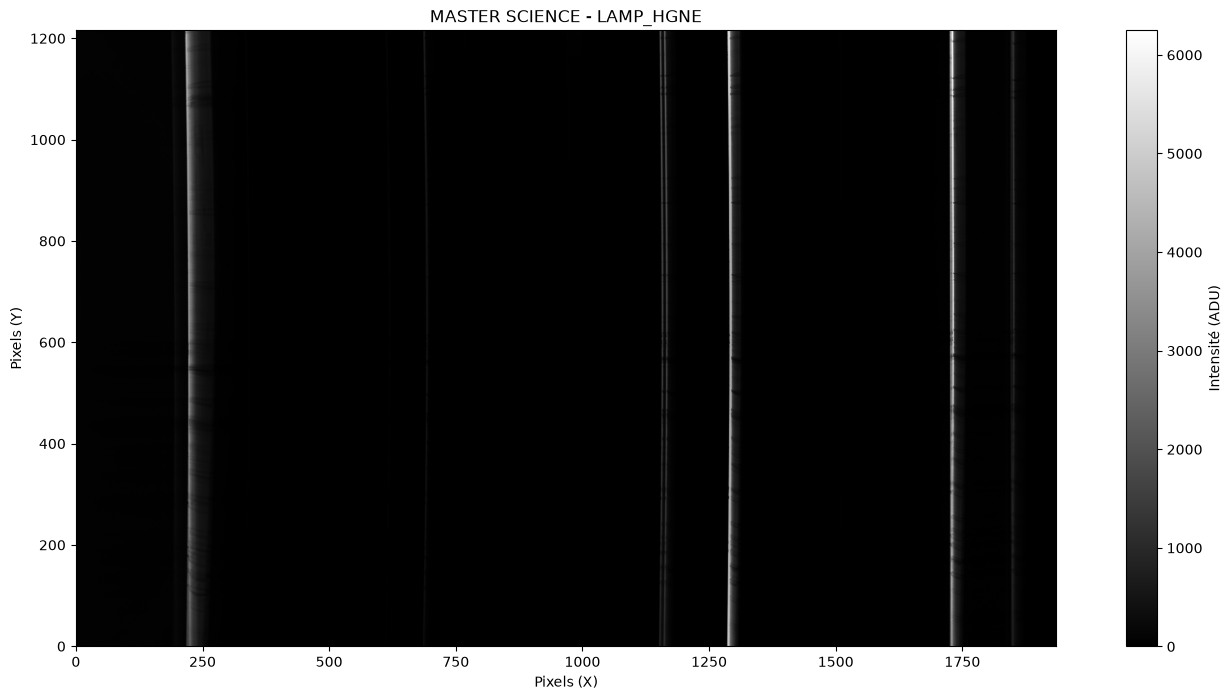

In [19]:
fig, ax = plt.subplots(figsize=(18,8))

im = ax.imshow(MASTER_SCIENCE, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER SCIENCE - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

### <span style="color:red">TODO : Think if I should create a FITS file for the final science calibrated image</span>.

## **6. Spectra extraction**

### Function

> **The spectra array needs to be reverse, as the +1 order on the detector is red on left and blue on right**

In [20]:
def spectra_plot(m_science, header, log=False, ylines=[0,607,1215],xmin=0,xmax=1936):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

    # m_science = header
    for line in ylines:
        if log:
            ax1.plot(np.log10(m_science[line,:][::-1] + 1 + np.abs(np.min(m_science[line,:][::-1]))),marker='.',ls='',label=f'Line : {line}') # reverse
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)
        else:
            ax1.plot(m_science[line,:][::-1],marker='.',ls='',label=f'Line : {line}')
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)

    # ax1.set_title(f"FITS - {header['DATE-OBS']}\n EXP : {header['EXPTIME']} - GAIN : {header['GAIN']}\n OBJ : {header['OBJECT']}- RA : {header['RA']} - DEC : {header['DEC']}")
    ax1.set_xlabel("Pixels (X)")
    ax1.set_ylabel("Intensity (ADU)")
    ax1.legend()
    

    ax1.grid(ls='--',c='lightgrey')
    ax1.set_axisbelow(True)
    ax1.set_xlim(xmin,xmax)



    im = ax2.imshow(m_science, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
    # On trace la ligne rouge horizontale là où la coupe est faite
    
    ax2.set_title("Detector image (2D)")
    ax2.set_xlabel("Pixels (X)")
    ax2.set_ylabel("Pixels (Y)")
    ax2.legend(loc='upper right')

    fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

    fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
                 f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
                 fontsize=12, y=0.98)

    plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
    plt.show()

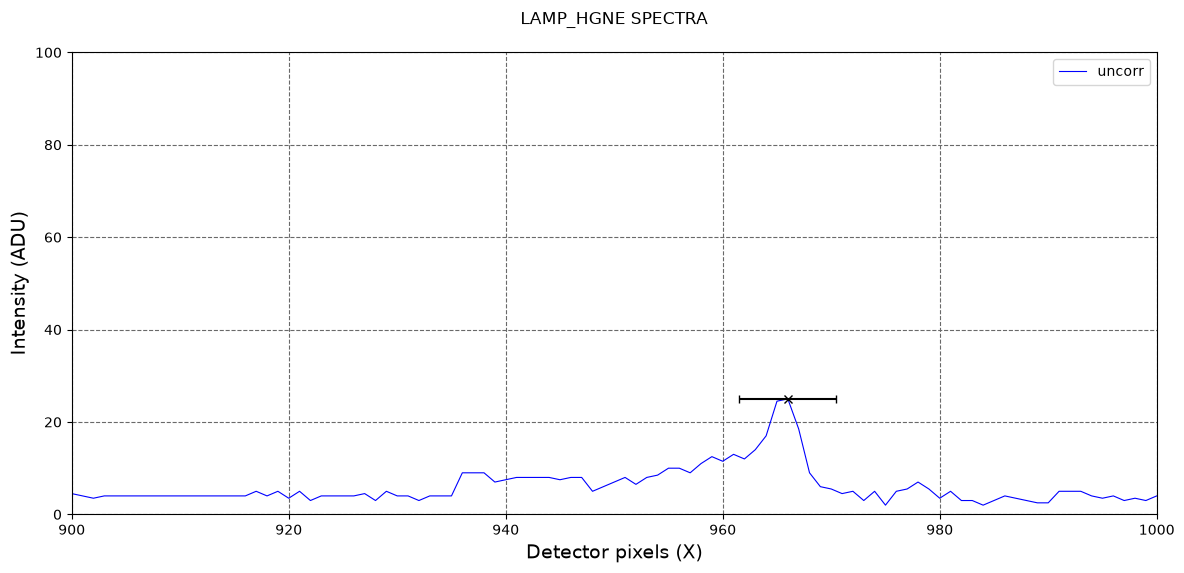

In [21]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,6))
colors = ['blue', 'red', 'green', 'purple']
lines = [1200]#,500,1000,1200]
for i, l in enumerate(lines):
    data = MASTER_SCIENCE_UNCORR[i,:][::-1]
    x, y = np.arange(1936), data

    peaks, prop = find_peaks(y, height=10, distance=7, prominence=4,width=2)#,threshold=100)

    ax.plot(x,(y),c=colors[i],lw=0.8,label='uncorr')

ax.errorbar(x=peaks, y=(y[peaks]), xerr=prop['widths'],color='black',marker='x',ls='', capsize=3)

ax.grid(ls='--',c='dimgrey')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
ax.set_title(f'{OBJECT_NAME} SPECTRA\n')
# ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)
# ax.set_xlim(760,790)
# ax.set_xlim(150,250) # 
# ax.set_xlim(620,670)
# ax.set_xlim(50,120)
# ax.set_ylim(0,3000)
# ax.set_yscale('log')
ax.set_ylim(0,100)
ax.set_xlim(900,1000)
ax.axhline(4096)
ax.legend()
plt.show()


In [22]:
# from lmfit.models import GaussianModel, ConstantModel

# model = GaussianModel(prefix='p1_') + GaussianModel(prefix='p2_') + ConstantModel()
# params = model.make_params(p1_center=774, p1_sigma=1.5, p1_amplitude=600,
#                             p2_center=782, p2_sigma=1.5, p2_amplitude=550,
#                             c=200)
# result = model.fit(MASTER_SCIENCE_UNCORR[600,:][::-1][760:790], params, x=np.arange(1936)[760:790])
# print(result.fit_report())

In [23]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import erfcx

def emg_left(x, A, mu, sigma, tau, c):
    sigma = np.abs(sigma)
    tau = np.abs(tau)
    u = (sigma**2 + tau*(x - mu)) / (sigma*tau*np.sqrt(2))
    return c + (A/(2*tau)) * np.exp(-(x-mu)**2/(2*sigma**2)) * erfcx(u)

def fwhm_numeric(func, popt, x_center, search_range=30, n_points=5000):
    """Calcule le FWHM numériquement à partir de la fonction fittée (EMG ou autre)."""
    A, mu, sigma, tau, c = popt
    x_fine = np.linspace(x_center - search_range, x_center + search_range, n_points)
    y_fine = func(x_fine, *popt)

    y_peak = y_fine.max() - c          # amplitude au-dessus du fond
    half_max = c + y_peak / 2

    above = y_fine >= half_max
    if not above.any():
        return np.nan

    idx = np.where(above)[0]
    x_left = x_fine[idx[0]]
    x_right = x_fine[idx[-1]]
    return x_right - x_left

def fit_peak(x, y, x0, amp_guess, all_peak_positions, left_win_max=16, right_win_max=4):
    others = [p for p in all_peak_positions if p != x0]
    left_neighbors = [p for p in others if p < x0]
    right_neighbors = [p for p in others if p > x0]

    left_win = min(left_win_max, (x0 - max(left_neighbors)) / 2) if left_neighbors else left_win_max
    right_win = min(right_win_max, (min(right_neighbors) - x0) / 2) if right_neighbors else right_win_max
    left_win = max(left_win, 10)
    right_win = max(right_win, 10)

    mask = (x > x0 - left_win) & (x < x0 + right_win)
    xf, yf = x[mask], y[mask]

    far_left_mask = (x > x0 - left_win) & (x < x0 - left_win + 5)
    baseline_guess = np.median(y[far_left_mask]) if far_left_mask.sum() > 0 else np.percentile(yf, 5)

    # baseline_guess = 20
    # left_win = 30
    # right_win = 30
    p0 = [amp_guess * 3, x0, 2.0, 5.0, baseline_guess]
    bounds = (
        [0,             x0 - left_win/2,  0.3, 0.2, 0],
        [amp_guess*20,  x0 + right_win/2, 15,  30,  baseline_guess*2 + 10]
    )

    try:
        popt, pcov = curve_fit(emg_left, xf, yf, p0=p0, bounds=bounds, maxfev=30000)
        
        if not np.all(np.isfinite(popt)) or not np.all(np.isfinite(pcov)):
            return None, None, xf, yf, np.nan
        fwhm = fwhm_numeric(emg_left, popt, x_center=popt[1], search_range=max(left_win, right_win)*1.5)
        return popt, pcov, xf, yf, fwhm
    except (RuntimeError, ValueError, TypeError):
        return None, None, xf, yf, np.nan


# ---------------------------------------------------------------------------
# Tracking sur plusieurs lignes
# ---------------------------------------------------------------------------
tracks = defaultdict(list)
next_id = 0
last_row_peaks = {}
tol = 1.2#1.5

n_rows = MAX_H # nombre de rangées horizontales
rows = np.arange(0, n_rows, 5)  # échantillonne toutes les 10 lignes, ajuste selon besoin


x_complet = np.arange(MAX_W)

for row in tqdm(rows):
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
    peaks, prop = find_peaks(y_row,  height=10, distance=7, prominence=4,width=2)#,plateau_size=5)
    peak_positions = x_complet[peaks]
    # print(peak_positions)

    current_row_peaks = {}

    for pk in peaks:
        p_entier = int(x_complet[pk])

        popt, pcov, xf, yf, fwhm = fit_peak(
            x_complet, y_row, x_complet[pk], y_row[pk], peak_positions
        )

        # --- matching avec la ligne precedente (meme si le fit a echoue) ---
        matched_id = None
        for x_prev, tid in last_row_peaks.items():
            if abs(p_entier - x_prev) < tol:
                matched_id = tid
                break
        if matched_id is None:
            matched_id = next_id
            next_id += 1

        # matched_id = None
        # best_dist = tol
        # for x_prev, tid in last_row_peaks.items():
        #     d = abs(p_entier - x_prev)
        #     if d < best_dist:
        #         best_dist = d
        #         matched_id = tid

        if popt is None:
            tracks[matched_id].append({
                'row': row,
                'peak_pixel_raw': p_entier,
                'fit_success': False,
            })
            current_row_peaks[p_entier] = matched_id
            continue

        A, mu, sigma, tau, c = popt
        # fwhm_test = fwhm_numeric()
        perr = np.sqrt(np.diag(pcov))
        A_err, mu_err, sigma_err, tau_err, c_err = perr

        xx = np.linspace(xf.min(), xf.max(), 1000)
        yy_fit = emg_left(xx, *popt)
        idx_max = np.argmax(yy_fit)
        vrai_sommet_x = xx[idx_max]
        vrai_sommet_y = yy_fit[idx_max]


        tracks[matched_id].append({
            'row': row,
            'peak_pixel_raw': p_entier,
            'fit_success': True,
            'mu': mu,
            'mu_err': mu_err,
            'A': A,
            'A_err': A_err,
            'sigma': sigma,
            'sigma_err': sigma_err,
            'tau': tau,
            'tau_err': tau_err,
            'c': c,
            'c_err': c_err,
            'sommet_x': vrai_sommet_x,
            'sommet_y': vrai_sommet_y,
            'fwhm': fwhm, 
        })

        current_row_peaks[p_entier] = matched_id

    last_row_peaks = current_row_peaks

  0%|          | 0/244 [00:00<?, ?it/s]/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_421/3766709504.py:12: RuntimeWarning: invalid value encountered in multiply
  return c + (A/(2*tau)) * np.exp(-(x-mu)**2/(2*sigma**2)) * erfcx(u)
100%|██████████| 244/244 [00:58<00:00,  4.16it/s]


In [24]:
import pandas as pd

rows_list = []
for track_id, entries in tracks.items():
    for entry in entries:
        row_dict = {'track_id': track_id}
        row_dict.update(entry)
        rows_list.append(row_dict)

df_tracks = pd.DataFrame(rows_list)
df_tracks = df_tracks.sort_values(['track_id', 'row']).reset_index(drop=True)

## **8. Emission line plot and sorting/filter for calibration**
---

### **8.a Choosing and plotting filtered emission line to validate for fitting**

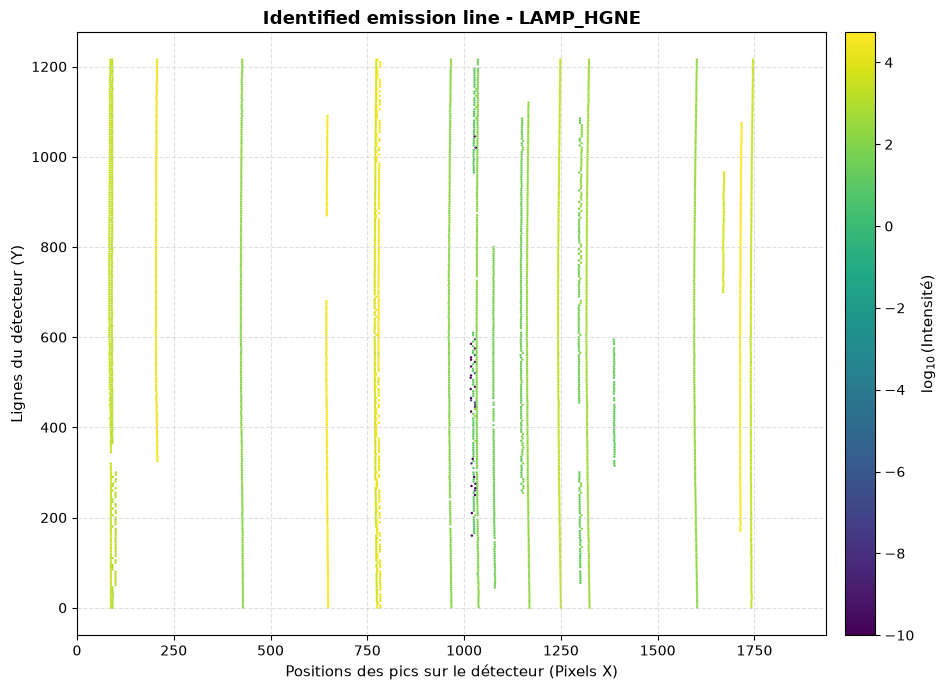

In [25]:
MIN_POINTS = 40 # chosen minimum amount of point to be considered a valid emission line

track_lengths = df_tracks.groupby('track_id')['row'].transform('count') # convert as count to see how many point are associated to emission line
df_plot = df_tracks[(track_lengths > MIN_POINTS) & df_tracks['fit_success']].copy() # we only keep emission line from valid fit and with enought point associated to said emission line

df_plot['A_clipped'] = df_plot['A'].clip(lower=1e-10)
df_plot['log_A'] = np.log10(df_plot['A_clipped'])

vmin, vmax = df_plot['log_A'].min(), df_plot['log_A'].max()

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df_plot['mu'],
    df_plot['row'],
    c=df_plot['log_A'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    s=12,
    marker='.',
    edgecolor='none',
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log_{10}(\mathrm{Intensité})$', fontsize=11)

ax.set_xlabel('Positions des pics sur le détecteur (Pixels X)', fontsize=11)
ax.set_ylabel('Lignes du détecteur (Y)', fontsize=11)
ax.set_title(f"Identified emission line - {OBJECT_NAME}", fontsize=13, weight='bold')
ax.grid(True, linestyle='--', color='lightgrey', alpha=0.7)
ax.set_xlim(0, MAX_W)

plt.tight_layout()
plt.show()

In [26]:
# Here, we can choose to only keep 'clean' emission line, based on the minimum amount of point associated to said line (MIN_POINTS)
track_lengths = df_tracks.groupby('track_id')['row'].count()
valid_ids = track_lengths[track_lengths >= MIN_POINTS].index  # seuil à ajuster
df_tracks_clean = df_tracks[df_tracks['track_id'].isin(valid_ids)].reset_index(drop=True)
# df_tracks_clean.info()

In [27]:
# Visualisation of left valid emission line in dataframe
valid_ids = df_tracks_clean['track_id'].unique()
print(valid_ids)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  14  56  67 139 146
 184 187 220 224 229 239 246 292 418 485 521 660 725]


In [28]:
def pipeline_calibration_geometrique(
    df_tracks, n_sigma=1.5, iters=3, min_points=50, sigma_inst=0.1
):
    """Calcule le fit parabolique de chaque trace en éliminant le bruit et les
    sauts de raie par sigma-clipping itératif, puis calcule le Chi2 réduit.

    Attend un DataFrame avec au minimum les colonnes :
    'track_id', 'row', 'mu', 'A', 'sigma', 'c', 'fit_success'

            tracks[matched_id].append({
            'row': row,
            'peak_pixel_raw': p_entier,
            'fit_success': True,
            'mu': mu,
            'mu_err': mu_err,
            'A': A,
            'A_err': A_err,
            'sigma': sigma,
            'sigma_err': sigma_err,
            'tau': tau,
            'tau_err': tau_err,
            'c': c,
            'c_err': c_err,
            'sommet_x': vrai_sommet_x,
            'sommet_y': vrai_sommet_y,
        })
    """
    fits = {}

    for track_id, group in df_tracks.groupby('track_id'):
        # On ne garde que les lignes où le fit EMG a réussi
        group = group[group['fit_success']]

        if len(group) < min_points:
            continue

        rows_t = group['row'].to_numpy()
        x_t = group['sommet_x'].to_numpy()
        insty = group['A'].to_numpy()
        std = group['sigma'].to_numpy()
        noise = group['c'].to_numpy()
        fwhm_t = group['fwhm'].to_numpy()
        mu_err = group['mu_err'].to_numpy()
        
        # ! Emission filtering from line intensity ######
        seuil_intensite = np.median(insty) * 0.1  # remove too faint emission line, might not be useful, need to see later
        mask_lumineux = insty > seuil_intensite
        # ! #####

        rows_clean = rows_t[mask_lumineux]
        x_clean = x_t[mask_lumineux]
        insty_clean = insty[mask_lumineux]
        std_clean = std[mask_lumineux]
        noise_clean = noise[mask_lumineux]
        mu_err_clean = mu_err[mask_lumineux]
        fwhm_clean = fwhm_t[mask_lumineux]

       

        # BOUCLE DE SIGMA-CLIPPING ITERATIF
        for i in range(iters):
            if len(x_clean) < min_points:
                break  # trop purgé

            coeffs_temp = np.polyfit(rows_clean, x_clean, deg=2)
            x_mod_temp = np.polyval(coeffs_temp, rows_clean)

            residus = x_clean - x_mod_temp
            std_residus = np.std(residus)

            if std_residus < 1e-5:
                break

            mask = np.abs(residus) < (n_sigma * std_residus) # mask meaning we only consider value whose std are below a certain n-sigma (std) value
            # that way, we can remove big outlier from fit to ensure accuracy

            rows_clean = rows_clean[mask]
            x_clean = x_clean[mask]
            insty_clean = insty_clean[mask]
            std_clean = std_clean[mask]
            noise_clean = noise_clean[mask]
            mu_err_clean = mu_err_clean[mask]
            fwhm_clean = fwhm_clean[mask]

        

        # FIT FINAL ET CALCUL DU CHI2 NORMALISÉ
        if len(x_clean) >= 20: 
            mu_err_clean = np.clip(mu_err_clean, a_min=0.01, a_max=2.0)
            poids = 1.0 / mu_err_clean
            
            # Le fit pondéré
            res_final = np.polyfit(rows_clean, x_clean, deg=2, full=True, w=poids)

            coeffs_finals = res_final[0]
            ssr_array = res_final[1]

            dof = len(x_clean) - 3

            if len(ssr_array) > 0 and dof > 0:
                ssr = ssr_array[0]
                # CORRECTION : ssr contient déjà les poids (1/mu_err)^2. 
                # On divise simplement par les degrés de liberté (dof).
                chi2_norm = ssr / dof 
            else:
                chi2_norm = np.nan


            fits[track_id] = (
                coeffs_finals,
                rows_clean,
                x_clean,
                insty_clean,
                chi2_norm,
                std_clean,
                noise_clean,
                fwhm_clean,
            )

    return fits

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def plot_track_and_residuals(fits_dict, track_id):
    # 1. Vérifier si l'identifiant existe
    if track_id not in fits_dict:
        print(f"Le track_id {track_id} n'est pas dans le dictionnaire 'fits'.")
        return

    # Extraire les données stockées
    coeffs, rows_t, x_t, insty, chi2_norm, std, noise, fwhm = fits_dict[track_id]

    # --- CORRECTION 1 : Une vraie grille continue pour le tracé de la ligne ---
    # Au lieu d'utiliser len(x_t), on crée 1000 points parfaits de 0 à 1200 (la hauteur du CCD)
    rows_virtuelles = np.linspace(np.min(rows_t), np.max(rows_t), 1000)
    x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

    # --- CORRECTION 2 : Calcul des résidus EXACTEMENT sur les vrais points ---
    # Pour calculer le résidu d'un point réel, il faut évaluer la parabole sur sa vraie ligne !
    x_fit_points_reels = np.polyval(coeffs, rows_t)
    residuals = x_t - x_fit_points_reels

    sns.set_theme(style="whitegrid")
    fig, (ax_main, ax_res) = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Affichage des points de données (avec le trou, c'est normal !)
    sns.scatterplot(
        x=rows_t,
        y=x_t,
        hue=insty,  # Optionnel : réactivé pour voir l'intensité en couleur !
        palette="viridis",
        ax=ax_main,
        alpha=0.8,
        edgecolor=None,
    )

    ax_main.errorbar(
        x=rows_t,
        y=x_t,
        yerr=1/3*std,  # Remplace par ton tableau 'std' si tu as une erreur par point
        fmt="none",  # CRUCIAL : dit à Matplotlib de ne pas dessiner de points
        ecolor="gray",  # Une couleur sobre (ex: gris) pour ne pas polluer ta palette viridis
        elinewidth=0.8,  # Épaisseur fine pour que ce soit élégant
        capsize=1.5,  # Largeur des petits ergots horizontaux au bout des barres
        alpha=0.4,  # Légère transparence pour ne pas surcharger visuellement si tu as beaucoup de points
    )

    # --- CORRECTION 3 : On trace la ligne rouge avec les variables virtuelles ---
    sns.lineplot(
        x=rows_virtuelles,  # On utilise la grille sans trou
        y=x_fit_virtuel,  # Et le fit sans trou
        color="red",
        linewidth=2.5,
        ax=ax_main,
        label=f"Fit Deg 2 (ID: {track_id}) - Chi2 {chi2_norm:.2f}",
    )

    ax_main.set_ylabel("Position X")
    ax_main.set_title(
        f"Ajustement Parabolique et Résidus pour la Trace n°{track_id}",
        fontsize=14,
    )
    ax_main.legend()

    # --- GRAPHIQUE DES RÉSIDUS ---
    sns.scatterplot(
        x=rows_t,
        y=residuals,
        color="purple",
        alpha=0.6,
        ax=ax_res,
        edgecolor=None,
    )
    # Ligne horizontale à 0 (le fit parfait)
    ax_res.axhline(y=0, color="black", linestyle="--", linewidth=1.5)

    ax_res.set_xlabel("Lignes (Rows)")
    ax_res.set_ylabel("Résidus (Data - Fit)")
    

    plt.tight_layout()
    plt.show()

Available ids = [3, 5, 6, 7, 9, 10, 11, 12, 14, 56, 146, 229, 239, 246, 292]


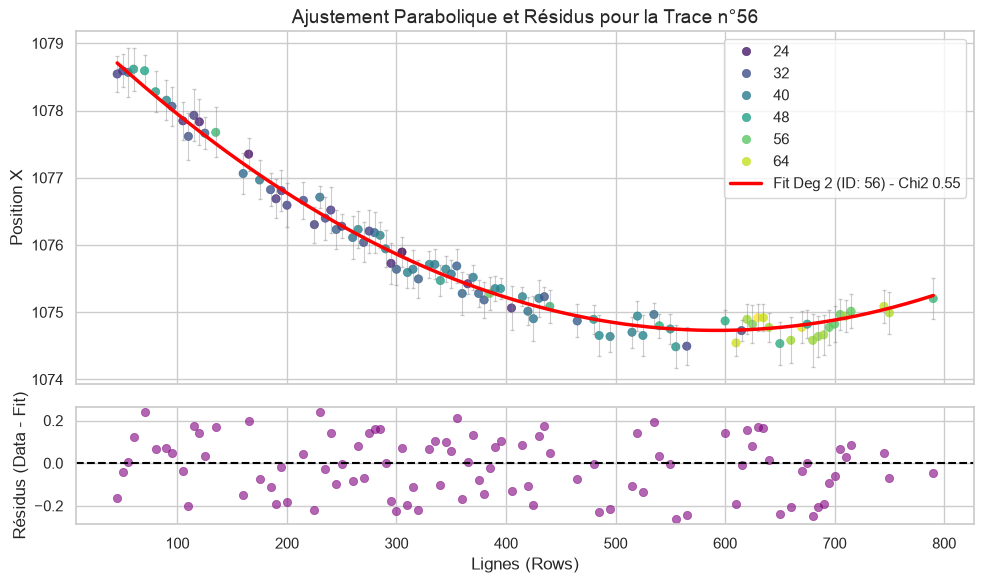

In [30]:
# amplitude_mask = df_tracks['sommet_y'] > 2000
# df_ampMask = df_tracks[amplitude_mask]

fits = pipeline_calibration_geometrique(
    df_tracks, n_sigma=1.5, iters=3, min_points=100, sigma_inst=0.15
)

available_ids = list(fits.keys())
print(f'Available ids = {available_ids}')

if available_ids:
    target_id = available_ids[9]
    plot_track_and_residuals(fits, target_id)

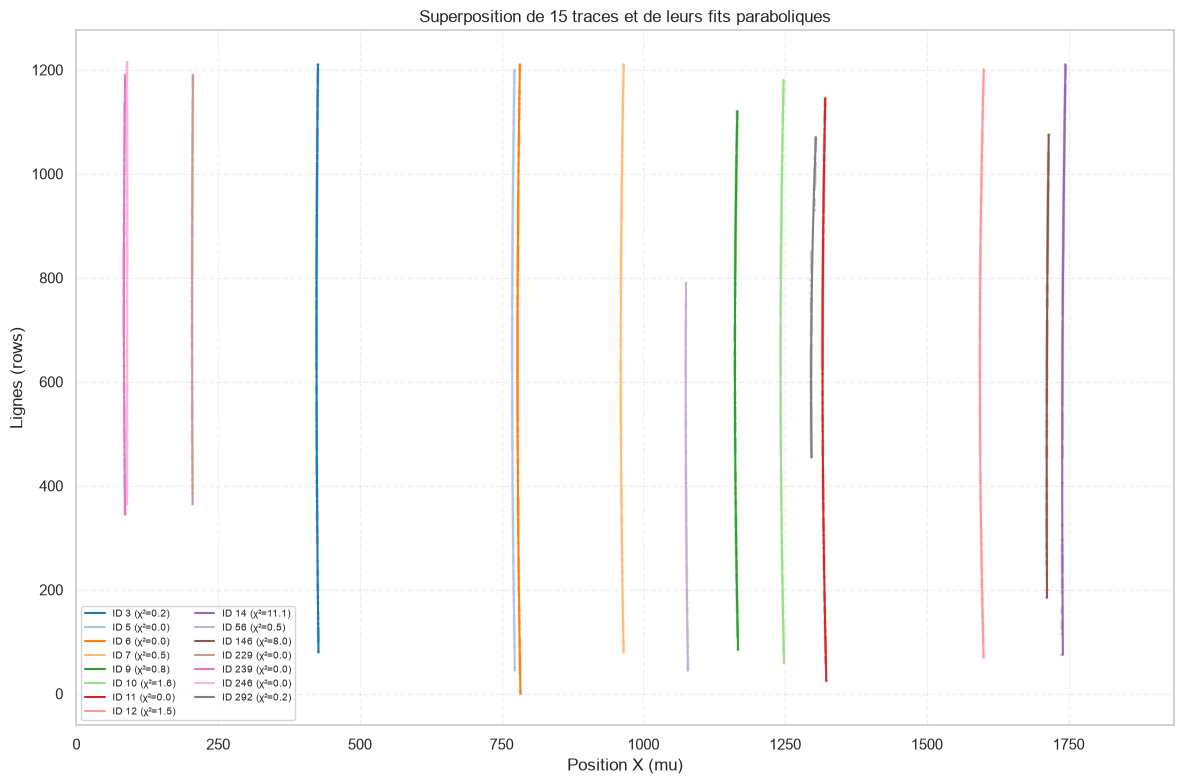

In [31]:
import matplotlib.pyplot as plt
import numpy as np


def plot_all_tracks_and_fits(fits_dict, alpha_points=0.4, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.get_cmap('tab20')  # 20 couleurs distinctes, se répète après
    n = len(fits_dict)

    for i, (track_id, data) in enumerate(fits_dict.items()):
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
        color = cmap(i % 20)

        # points de données
        ax.scatter(x_clean,
            rows_clean,
            s=6, alpha=alpha_points, color=color, edgecolor='none'
        )

        # fit parabolique (grille continue pour une ligne lisse)
        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

        ax.plot(x_fit_virtuel,
            rows_virtuelles,
            color=color, linewidth=1.5,
            label=f'ID {track_id} (χ²={chi2_norm:.1f})'
        )

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title(f'Superposition de {n} traces et de leurs fits paraboliques')
    ax.grid(True, linestyle='--', alpha=0.3)

    # légende : peut vite devenir énorme si beaucoup de tracks, donc on la limite
    if n <= 25:
        ax.legend(fontsize=7, ncol=2, loc='best')
    ax.set_xlim(0,MAX_W)
    plt.tight_layout()
    plt.show()


# utilisation
plot_all_tracks_and_fits(fits)

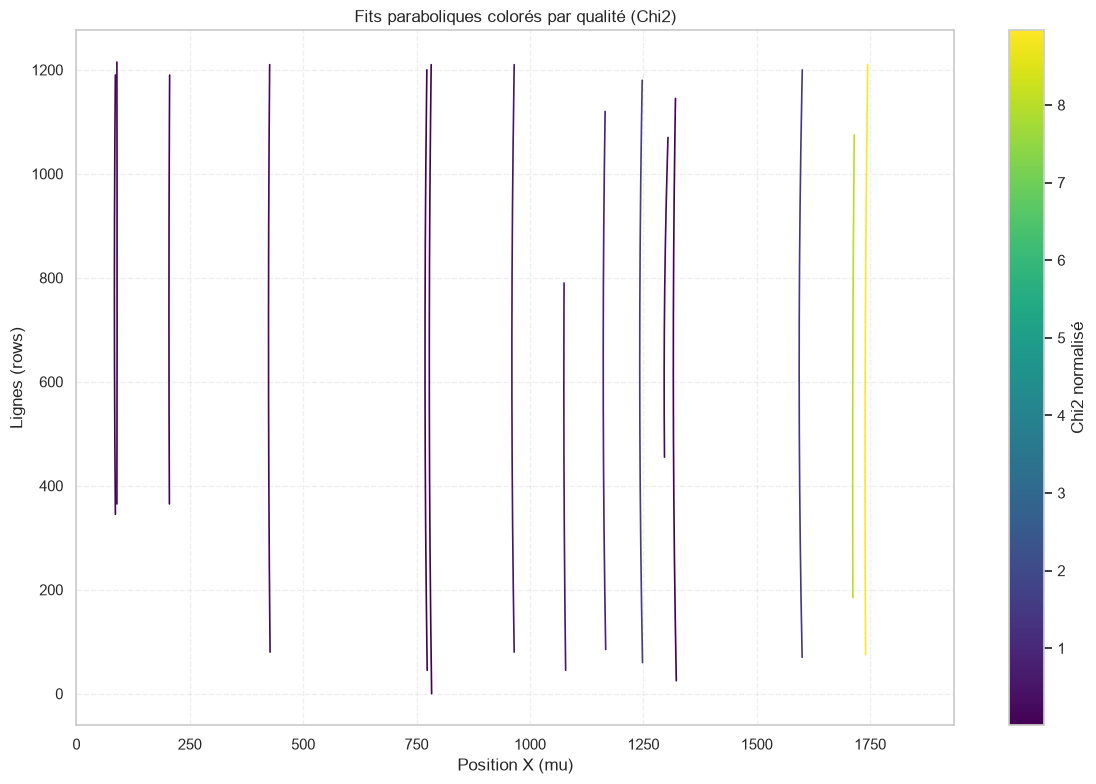

In [32]:
def plot_all_tracks_and_fits_by_chi2(fits_dict, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    chi2_values = [d[4] for d in fits_dict.values() if np.isfinite(d[4])]
    vmin, vmax = np.percentile(chi2_values, [5, 95])  # évite les outliers extrêmes

    cmap = plt.get_cmap('viridis')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
        norm_val = np.clip((chi2_norm - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

        ax.plot(x_fit_virtuel,rows_virtuelles,  color=color, linewidth=1.2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Chi2 normalisé')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title('Fits paraboliques colorés par qualité (Chi2)')
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    ax.set_xlim(0,MAX_W)
    plt.show()

plot_all_tracks_and_fits_by_chi2(fits)

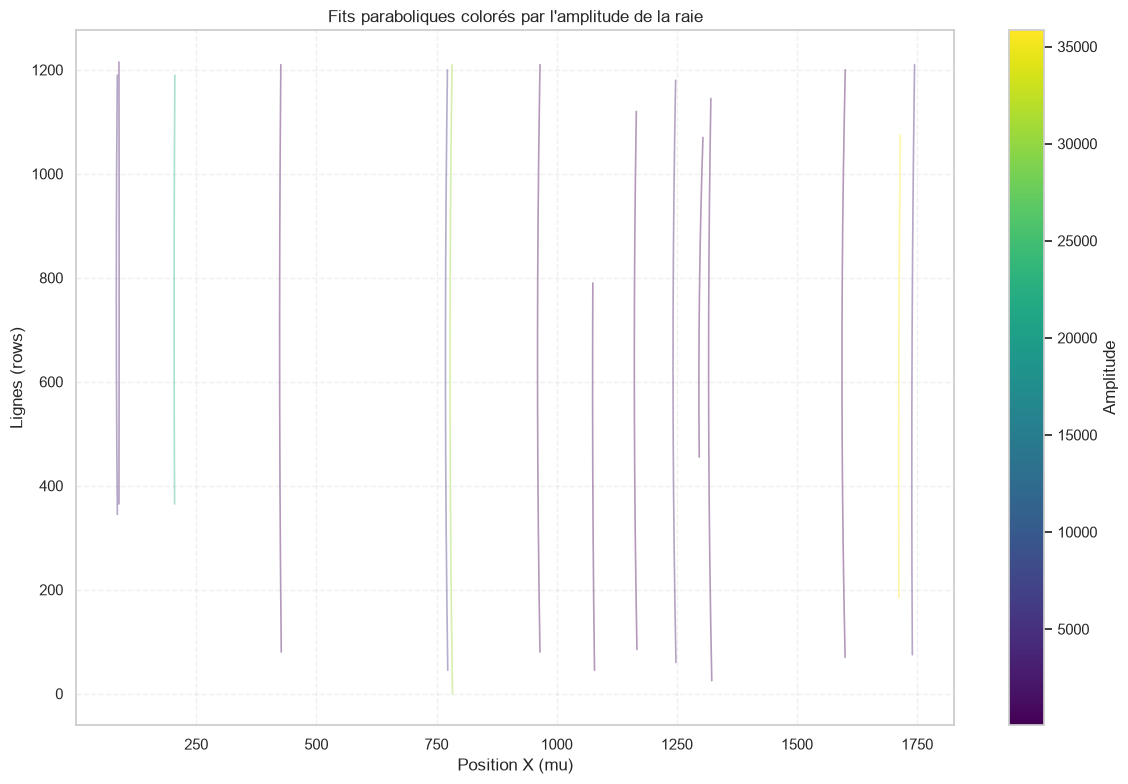

In [33]:
def plot_all_tracks_and_fits_by_amplitude(fits_dict, figsize=(12, 8), log_scale=True):
    fig, ax = plt.subplots(figsize=figsize)

    # amplitude représentative de chaque track (médiane sur tous ses points)
    amp_values = [np.median(d[3]) for d in fits_dict.values() if np.all(np.isfinite(d[3]))]

    if log_scale:
        amp_values = np.log10(np.clip(amp_values, 1e-10, None))

    vmin, vmax = np.percentile(amp_values, [5, 95])  # évite les outliers extrêmes
    cmap = plt.get_cmap('viridis')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data

        amp_med = np.median(insty_clean)
        if log_scale:
            amp_med = np.log10(max(amp_med, 1e-10))

        norm_val = np.clip((amp_med - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)
        fwhm = np.nanmedian(fwhm)

        err = ax.errorbar(
            x=x_fit_virtuel,
            y=rows_virtuelles,
            # xerr=fwhm,
            color=color,
            linewidth=1.2,
            capsize=3,
            ecolor='red',
            alpha=0.4
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'$\log_{10}$(Amplitude)' if log_scale else 'Amplitude')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title("Fits paraboliques colorés par l'amplitude de la raie")
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.set_xlim(0, 300)
    # ax.set_xlim(300, 600)
    # ax.set_xlim(600, 900)
    # ax.set_xlim(900, 1200)
    # ax.set_xlim(1200, MAX_W)
    plt.tight_layout()
    plt.show()


plot_all_tracks_and_fits_by_amplitude(fits,log_scale=False)

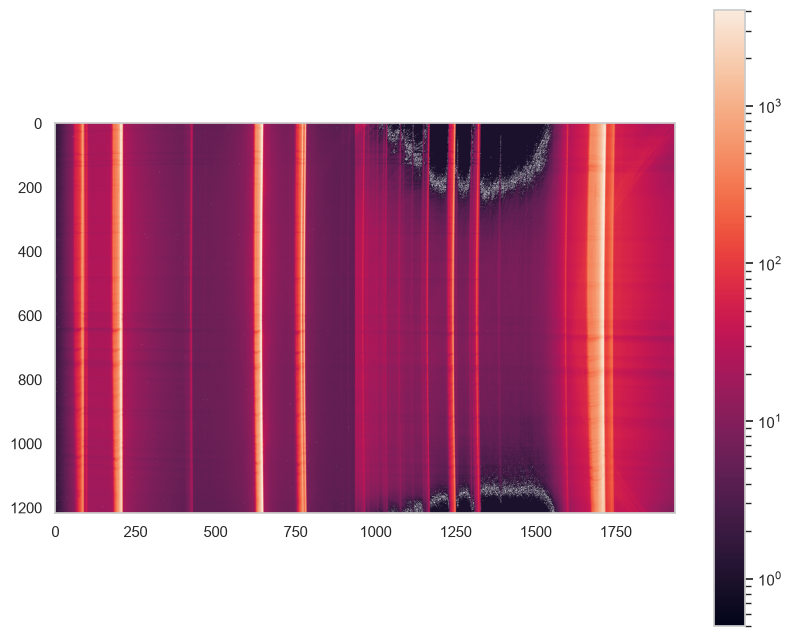

In [44]:
%matplotlib inline
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(10,8))
plt.imshow(np.flip(MASTER_SCIENCE_UNCORR[:,:]),norm=LogNorm())
# plt.xlim(0,300)
# plt.xlim(655,MAX_W)
plt.colorbar()
plt.grid(False)

404.64,491.6,576.94, 579.06, 703.24, 724.5, 794.3, 808.24, 813.64

### Visualisation FWHM sur le détecteur

In [45]:
def fit_fwhm_trend(rows_clean, fwhm_clean, deg=1):
    """Ajuste une tendance FWHM(row) lissée, robuste au bruit résiduel."""
    coeffs_fwhm = np.polyfit(rows_clean, fwhm_clean, deg=deg)
    return coeffs_fwhm

def eval_fwhm_trend(coeffs_fwhm, rows):
    return np.polyval(coeffs_fwhm, rows)

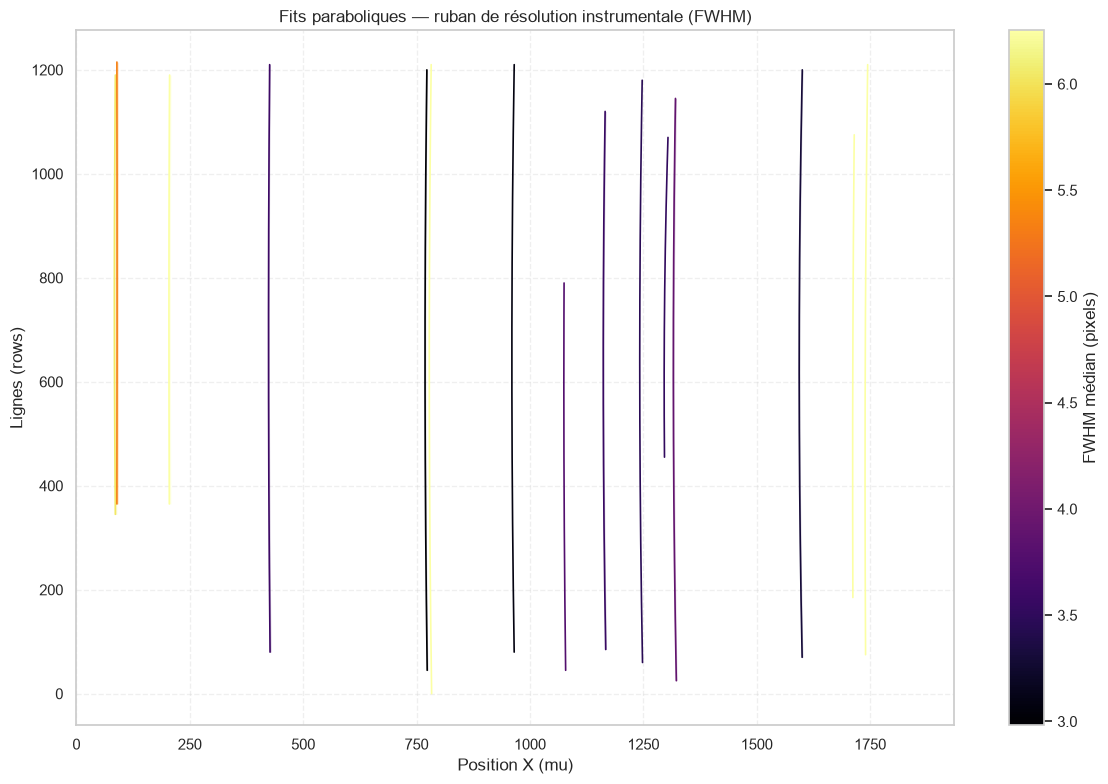

In [46]:
def plot_all_tracks_and_fits_by_fwhm(fits_dict, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    fwhm_medians = [np.nanmedian(d[7]) for d in fits_dict.values() if np.all(np.isfinite(d[7]))]
    vmin, vmax = np.nanpercentile(fwhm_medians, [5, 95])
    cmap = plt.get_cmap('inferno')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data

        if len(rows_clean) < 10 or not np.any(np.isfinite(fwhm_clean)):
            continue

        # tendance FWHM lissée le long de la raie (pas un scalaire unique)
        coeffs_fwhm = fit_fwhm_trend(rows_clean, fwhm_clean, deg=1)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 300)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)
        fwhm_fit = eval_fwhm_trend(coeffs_fwhm, rows_virtuelles)

        fwhm_med = np.nanmedian(fwhm_clean)
        norm_val = np.clip((fwhm_med - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        # trace centrale
        ax.plot(x_fit_virtuel, rows_virtuelles, color=color, linewidth=1.2)

        # ruban de largeur = FWHM local (demi-largeur de chaque côté)
        ax.fill_betweenx(
            rows_virtuelles,
            x_fit_virtuel - fwhm_fit / 2,
            x_fit_virtuel + fwhm_fit / 2,
            color=color, alpha=0.25, linewidth=0
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('FWHM médian (pixels)')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title("Fits paraboliques — ruban de résolution instrumentale (FWHM)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, MAX_W)
    plt.tight_layout()
    plt.show()


plot_all_tracks_and_fits_by_fwhm(fits)

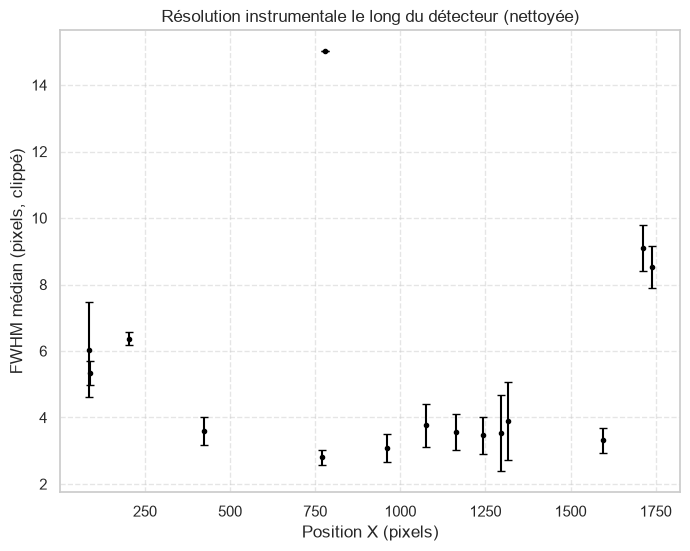

In [47]:
FWHM_med, FWHM_mad, FWHM_pos, FWHM_id = [], [], [], []

for tid, data in fits.items():
    coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data
    if not np.any(np.isfinite(fwhm_clean)):
        continue
    med = np.nanmedian(fwhm_clean)
    mad = np.nanmedian(np.abs(fwhm_clean - med)) * 1.4826  # équivalent robuste de l'écart-type
    FWHM_med.append(med)
    FWHM_mad.append(mad)
    FWHM_pos.append(np.median(x_clean))
    FWHM_id.append(tid)

fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(x=FWHM_pos, y=FWHM_med, yerr=FWHM_mad, ls='', marker='.', capsize=3, color='black')
ax.set_ylabel('FWHM médian (pixels, clippé)')
ax.set_xlabel('Position X (pixels)')
ax.set_title("Résolution instrumentale le long du détecteur (nettoyée)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

---

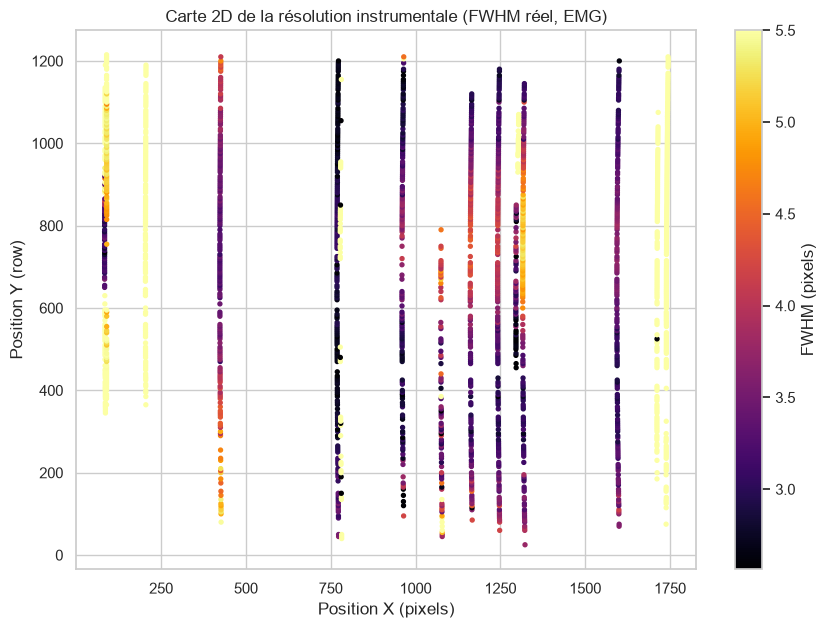

In [48]:
rows_all, x_all, fwhm_all = [], [], []

for tid, data in fits.items():
    coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data
    rows_all.extend(rows_clean)
    x_all.extend(x_clean)
    fwhm_all.extend(fwhm_clean)

rows_all = np.array(rows_all)
x_all = np.array(x_all)
fwhm_all = np.array(fwhm_all)

fig, ax = plt.subplots(figsize=(10,7))
sc = ax.scatter(x_all, rows_all, c=fwhm_all, cmap='inferno', s=8,
                 vmin=np.nanpercentile(fwhm_all,2), vmax=5.5)#np.nanpercentile(fwhm_all,98))
fig.colorbar(sc, label='FWHM (pixels)')
ax.set_xlabel('Position X (pixels)')
ax.set_ylabel('Position Y (row)')
ax.set_title('Carte 2D de la résolution instrumentale (FWHM réel, EMG)')
plt.show()

## **8. Longueur d'onde**

In [39]:
# first fit try
# longueurs_onde_triees = [585.24, 
#                          588.18, 
#                          594.48, 
#                          597.54, 
#                          602.98, 
#                          607.42, 
#                          609.60, 
#                          614.32, 
#                          616.34, 
#                          621.72, 
#                          626.64, 
#                          630.46, 
#                          633.44, 
#                          640.22, 
#                          650.64, 
#                          653.28, 
#                          659.88, 
#                          667.82, 
#                          671.70, 
#                          692.94,
#                          724.46,
#                          743.88]

In [40]:
# second try exp 50000
# longueurs_onde_triees = [404.64, 
#                          491.6, 
#                          576.94,
#                          579.06,
#                          703.24,
#                          724.5,
#                          794.3,
#                          808.24,
#                          813.64,
#                         ]

In [41]:
# # third try, work for low exposure
# longueurs_onde_triees = [404.64, 
#                          435.82,
#                          491.6, 
#                          546.06,
#                          576.94,
#                          579.06,
#                          692.94,
#                         #  703.24,
#                          808.24,
#                         #  703.24,
#                         #  724.5,
#                         #  794.3,
#                         #  808.24,
#                         #  813.64,
#                         ]

In [49]:
longueurs_onde_triees = [404.64, 
                         407.76,
                         435.82,
                         491.6, 
                         546.06,
                         576.94,
                         579.06,
                         614.32,
                         650.64,
                         671.74,
                         692.94,
                         703.24,
                         705.9,
                         794.3,
                         808.24,
                        #  808.24,
                        #  703.24,
                        #  724.5,
                        #  794.3,
                        #  808.24,
                        #  813.64,
                        ]

# longueurs_onde_triees = [585.24, 
#                          588.18, 
#                          594.48, 
#                          597.54, 
#                          602.98, 
#                          607.42, 
#                          609.60, 
#                          614.32, 
#                          616.34, 
#                          621.72, 
#                          626.64, 
#                          630.46, 
#                          633.44, 
#                          640.22, 
#                          650.64, 
#                          653.28, 
#                          659.88, 
#                          667.82, 
#                          671.70, 
#                          692.94,
#                          724.46,
#                          743.88]

### 1. Tri des tracks par position et association aux longueurs d'onde connues

In [50]:
import numpy as np

# Tri des tracks par position moyenne en X (du plus à gauche au plus à droite)
fits_sorted = dict(sorted(fits.items(), key=lambda item: np.median(item[1][2])))

print(f"{len(fits_sorted)} raies triées : {list(fits_sorted.keys())}")

# --- Catalogue des longueurs d'onde connues (à adapter selon ta lampe) ---
# ATTENTION : l'ordre doit correspondre à l'ordre spatial des raies (gauche -> droite)


# Sécurité : vérifier que le nombre de raies identifiées correspond au catalogue
assert len(fits_sorted) == len(longueurs_onde_triees), (
    f"Mismatch: {len(fits_sorted)} tracks détectées vs "
    f"{len(longueurs_onde_triees)} longueurs d'onde fournies"
)

raies_physiques = {
    tid: wl for tid, wl in zip(fits_sorted.keys(), longueurs_onde_triees)
}

15 raies triées : [239, 246, 229, 3, 5, 6, 7, 56, 9, 10, 292, 11, 12, 146, 14]


### 2. Calibration géométrique 2D (une loi de dispersion par ligne Y)

### **2.a Tentative de fit par une ellipse plutot qu'une parabole**

In [51]:
def fit_ellipse(row_pts, x_pts):
    """Fit conique générale par SVD (moindres carrés algébriques)."""
    x = np.asarray(x_pts, dtype=float)
    y = np.asarray(row_pts, dtype=float)
    D = np.column_stack([x**2, x*y, y**2, x, y, np.ones_like(x)])
    _, _, Vt = np.linalg.svd(D)
    return Vt[-1, :]  # A, B, C, D, E, F

def eval_ellipse(coeffs, row, x_ref=None):
    """
    Résout x pour un row donné (racine du polynôme quadratique en x).
    x_ref : valeur de référence (ex: prédiction parabolique) pour choisir
            la bonne racine si les deux sont valides.
    """
    A, B, C, D, E, F = coeffs
    a = A
    b = B * row + D
    c = C * row**2 + E * row + F
    disc = b**2 - 4 * a * c

    scalar_input = np.isscalar(row) or np.ndim(row) == 0
    disc = np.atleast_1d(disc).astype(float)
    b = np.atleast_1d(b).astype(float) * np.ones_like(disc)

    disc_safe = np.where(disc < 0, np.nan, disc)
    x1 = (-b + np.sqrt(disc_safe)) / (2 * a)
    x2 = (-b - np.sqrt(disc_safe)) / (2 * a)

    if x_ref is not None:
        x_ref = np.atleast_1d(x_ref)
        choix = np.where(np.abs(x1 - x_ref) < np.abs(x2 - x_ref), x1, x2)
    else:
        choix = np.where(np.abs(x1) < np.abs(x2), x1, x2)

    return choix[0] if scalar_input else choix

In [ ]:
resultats = {}

for tid, (coeffs_para, rows_clean, x_clean, insty_clean,
              chi2_norm, std_clean, noise_clean, fwhm) in fits_sorted.items():

      rows_clean = np.asarray(rows_clean, dtype=float)
      x_clean = np.asarray(x_clean, dtype=float)

      # Fit ellipse
      c_ell = fit_ellipse(rows_clean, x_clean)

      # Prédictions sur les mêmes points que le polynôme
      x_pred_para = np.polyval(coeffs_para, rows_clean)
      x_pred_ell = eval_ellipse(c_ell, rows_clean, x_ref=x_pred_para)

      # Résidus
      resid_para = x_pred_para - x_clean
      resid_ell = x_pred_ell - x_clean

      # RMS
      rms_para = np.sqrt(np.nanmean(resid_para**2))
      rms_ell = np.sqrt(np.nanmean(resid_ell**2))

      resultats[tid] = {
            "rows": rows_clean,
            "x_clean": x_clean,
            "x_pred_para": x_pred_para,
            "x_pred_ell": x_pred_ell,
            "resid_para": resid_para,
            "resid_ell": resid_ell,
            "rms_para": rms_para,
            "rms_ell": rms_ell,
            "coeffs_ellipse": c_ell,
      }

      print(f"Raie {tid}: RMS parabole={rms_para:.4f}px, RMS ellipse={rms_ell:.4f}px")


Raie 239: RMS parabole=0.2194px, RMS ellipse=0.2166px
Raie 246: RMS parabole=0.0568px, RMS ellipse=0.0935px
Raie 229: RMS parabole=0.1448px, RMS ellipse=0.1744px
Raie 3: RMS parabole=0.1640px, RMS ellipse=0.0955px
Raie 5: RMS parabole=0.1148px, RMS ellipse=0.1249px
Raie 6: RMS parabole=0.1754px, RMS ellipse=0.3284px
Raie 7: RMS parabole=0.1095px, RMS ellipse=0.1678px
Raie 56: RMS parabole=0.1375px, RMS ellipse=0.3109px
Raie 9: RMS parabole=0.1163px, RMS ellipse=0.1968px
Raie 10: RMS parabole=0.1393px, RMS ellipse=0.1373px
Raie 292: RMS parabole=0.6664px, RMS ellipse=0.4000px
Raie 11: RMS parabole=0.0869px, RMS ellipse=0.0802px
Raie 12: RMS parabole=0.1073px, RMS ellipse=0.1463px
Raie 146: RMS parabole=0.1376px, RMS ellipse=0.2614px
Raie 14: RMS parabole=0.3105px, RMS ellipse=0.3213px


In [ ]:
# degre_calib = 2  # degré du polynôme Pixel X -> Lambda
# valid_tids = list(fits_sorted.keys())
# true_wavelengths = np.array([raies_physiques[tid] for tid in valid_tids])

# # Pré-calcul : fit ellipse pour chaque raie (une fois, hors boucle sur row)
# ellipse_coeffs = {}
# for tid in valid_tids:
#     coeffs_para, rows_clean, x_clean = fits_sorted[tid][0], fits_sorted[tid][1], fits_sorted[tid][2]
#     ellipse_coeffs[tid] = fit_ellipse(rows_clean, x_clean)

# calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))

# for row in range(int(MAX_H) + 1):
#     # prédiction parabolique = référence pour choisir la bonne racine de l'ellipse
#     x_ref_row = np.array([
#         np.polyval(fits_sorted[tid][0], row) for tid in valid_tids
#     ])
#     x_at_row = np.array([
#         eval_ellipse(ellipse_coeffs[tid], row, x_ref=x_ref_row[i])
#         for i, tid in enumerate(valid_tids)
#     ])

#     mask = ~np.isnan(x_at_row)
#     coeffs_calib = np.polyfit(x_at_row[mask], true_wavelengths[mask], deg=degre_calib)
#     calib_matrix[row, :] = coeffs_calib

# print("Calibration 2D terminée avec succès (fit elliptique) ! 🎉")

### **2.b Code utilisé précédemment avec fit parabolique**

In [52]:
resultats = {}

for tid, (coeffs_para, rows_clean, x_clean, insty_clean,
          chi2_norm, std_clean, noise_clean, fwhm) in fits_sorted.items():

    rows_clean = np.asarray(rows_clean, dtype=float)
    x_clean = np.asarray(x_clean, dtype=float)

    # Fit polynomial degree 2
    coeffs_poly = np.polyfit(rows_clean, x_clean, deg=2)

    # Predictions
    x_pred_poly = np.polyval(coeffs_poly, rows_clean)

    # Residuals
    resid_poly = x_pred_poly - x_clean

    # RMS
    rms_poly = np.sqrt(np.nanmean(resid_poly**2))

    resultats[tid] = {
        "rows": rows_clean,
        "x_clean": x_clean,
        "x_pred_poly": x_pred_poly,
        "resid_poly": resid_poly,
        "rms_poly": rms_poly,
        "coeffs_poly": coeffs_poly,
    }

    print(f"Raie {tid}: RMS polyfit deg2={rms_poly:.4f}px")


Raie 239: RMS polyfit deg2=0.2145px
Raie 246: RMS polyfit deg2=0.0544px
Raie 229: RMS polyfit deg2=0.1227px
Raie 3: RMS polyfit deg2=0.1008px
Raie 5: RMS polyfit deg2=0.1103px
Raie 6: RMS polyfit deg2=0.1634px
Raie 7: RMS polyfit deg2=0.1074px
Raie 56: RMS polyfit deg2=0.1351px
Raie 9: RMS polyfit deg2=0.1036px
Raie 10: RMS polyfit deg2=0.1308px
Raie 292: RMS polyfit deg2=0.5794px
Raie 11: RMS polyfit deg2=0.0722px
Raie 12: RMS polyfit deg2=0.1037px
Raie 146: RMS polyfit deg2=0.1267px
Raie 14: RMS polyfit deg2=0.2228px


In [53]:
degre_calib = 2  # degré du polynôme Pixel X -> Lambda

valid_tids = list(fits_sorted.keys())
true_wavelengths = np.array([raies_physiques[tid] for tid in valid_tids])

calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))
rms_by_row = []
for row in range(int(MAX_H) + 1):
    # position X théorique de chaque raie à cette ligne (via son fit parabolique)
    x_at_row = np.array([
        np.polyval(fits_sorted[tid][0], row) for tid in valid_tids
    ])

    # Lambda = f(X) pour cette ligne précise
    coeffs_calib = np.polyfit(x_at_row, true_wavelengths, deg=degre_calib)
    calib_matrix[row, :] = coeffs_calib

    wl_pred = np.polyval(coeffs_calib, x_at_row)
    rms = np.sqrt(np.mean((wl_pred - true_wavelengths) ** 2))
    rms_by_row.append(rms)

    if row % 100 == 0 or row in (0, int(MAX_H)):
        print(f"row={row:4d} | RMS={rms:.4f} nm")

print("\nRésumé du fit :")
print(f"RMS moyen   : {np.mean(rms_by_row):.4f} nm")
print(f"RMS médian  : {np.median(rms_by_row):.4f} nm")
print(f"RMS min/max : {np.min(rms_by_row):.4f} / {np.max(rms_by_row):.4f} nm")

# print("Calibration 2D terminée avec succès ! 🎉")

row=   0 | RMS=17.3683 nm
row= 100 | RMS=17.3342 nm
row= 200 | RMS=17.3055 nm
row= 300 | RMS=17.2812 nm
row= 400 | RMS=17.2606 nm
row= 500 | RMS=17.2433 nm
row= 600 | RMS=17.2289 nm
row= 700 | RMS=17.2171 nm
row= 800 | RMS=17.2082 nm
row= 900 | RMS=17.2021 nm
row=1000 | RMS=17.1993 nm
row=1100 | RMS=17.2003 nm
row=1200 | RMS=17.2058 nm
row=1216 | RMS=17.2071 nm

Résumé du fit :
RMS moyen   : 17.2465 nm
RMS médian  : 17.2278 nm
RMS min/max : 17.1992 / 17.3683 nm


In [ ]:
plt.plot(rms_by_row,marker='.',ls='')

### 3. Carte 2D de longueur d'onde

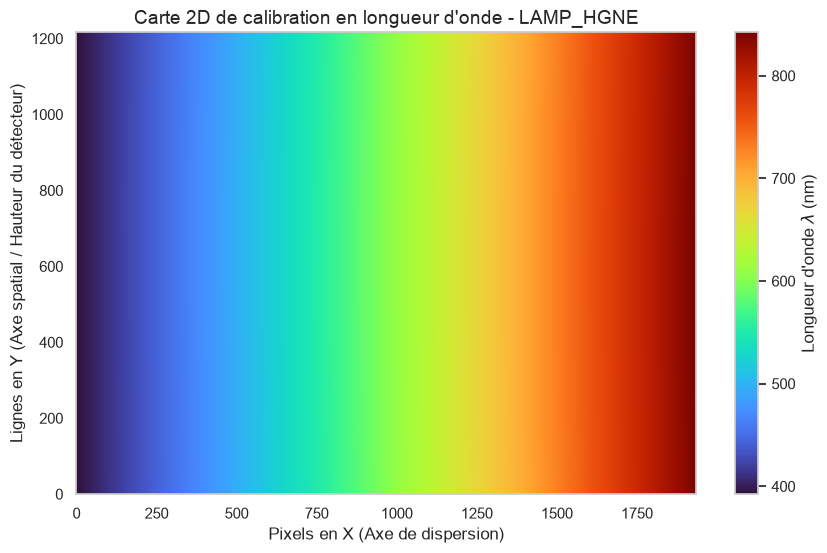

In [54]:
import matplotlib.pyplot as plt

x_pixels = np.arange(0, MAX_W)
wavelength_map_2D = np.zeros((int(MAX_H) + 1, MAX_W))

for row in range(int(MAX_H) + 1):
    wavelength_map_2D[row, :] = np.polyval(calib_matrix[row], x_pixels)

plt.figure(figsize=(10, 6))
plt.grid(False)
img = plt.imshow(wavelength_map_2D, aspect='auto', cmap='turbo', origin='lower')
cbar = plt.colorbar(img)
cbar.set_label(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.xlabel("Pixels en X (Axe de dispersion)", fontsize=12)
plt.ylabel("Lignes en Y (Axe spatial / Hauteur du détecteur)", fontsize=12)
plt.title(f"Carte 2D de calibration en longueur d'onde - {OBJECT_NAME}", fontsize=14)
# plt.xlim(200, 600)
plt.show()

### 4. Inspection du fit + résidus sur une ligne donnée

### **4.a Test elliptique et parabolique**

In [ ]:
# def plot_ellipse_fit(tid, fits_sorted, ellipse_coeffs):
#     coeffs_para, rows_clean, x_clean = fits_sorted[tid][0], fits_sorted[tid][1], fits_sorted[tid][2]
#     rows_clean = np.asarray(rows_clean, dtype=float)
#     x_clean = np.asarray(x_clean, dtype=float)
#     A, B, C, D, E, F = ellipse_coeffs[tid]

#     # grille pour dessiner la conique complète (contour implicite = 0)
#     x_grid = np.linspace(x_clean.min() - 100, x_clean.max() + 100, 400)
#     y_grid = np.linspace(0, max(rows_clean.max() * 1.5, 700), 400)
#     X, Y = np.meshgrid(x_grid, y_grid)
#     Z = A*X**2 + B*X*Y + C*Y**2 + D*X + E*Y + F

#     plt.figure(figsize=(6, 6))
#     plt.contour(X, Y, Z, levels=[0], colors='teal')
#     plt.scatter(x_clean, rows_clean, color='crimson', s=30, zorder=3, label='Points trackés')
#     plt.axhline(600, color='gray', linestyle='--', label='row = 600')
#     plt.gca().invert_yaxis()  # convention image : row croît vers le bas
#     plt.xlabel("X (pixels)")
#     plt.ylabel("Row (Y)")
#     plt.title(f"Raie {tid} : points vs ellipse fittée")
#     plt.legend()
#     plt.show()

# plot_ellipse_fit(3, fits_sorted, ellipse_coeffs)
# plot_ellipse_fit(4, fits_sorted, ellipse_coeffs)

In [ ]:
# def build_calib_matrix(x_at_row_func, fits_sorted, true_wavelengths, degre_calib, MAX_H):
#     valid_tids = list(fits_sorted.keys())
#     calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))
#     for row in range(int(MAX_H) + 1):
#         x_at_row = x_at_row_func(row, fits_sorted, valid_tids)
#         mask = ~np.isnan(x_at_row)
#         coeffs_calib = np.polyfit(x_at_row[mask], true_wavelengths[mask], deg=degre_calib)
#         calib_matrix[row, :] = coeffs_calib
#     return calib_matrix


# def x_row_parabole(row, fits_sorted, valid_tids):
#     return np.array([np.polyval(fits_sorted[tid][0], row) for tid in valid_tids])


# def x_row_ellipse(row, fits_sorted, valid_tids, ellipse_coeffs):
#     x_ref = x_row_parabole(row, fits_sorted, valid_tids)
#     return np.array([
#         eval_ellipse(ellipse_coeffs[tid], row, x_ref=x_ref[i])
#         for i, tid in enumerate(valid_tids)
#     ])


# # Pré-calcul des fits ellipse (une fois)
# ellipse_coeffs = {
#     tid: fit_ellipse(fits_sorted[tid][1], fits_sorted[tid][2])
#     for tid in fits_sorted.keys()
# }

# # Deux calibrations
# calib_matrix_para = build_calib_matrix(
#     lambda row, fs, vt: x_row_parabole(row, fs, vt),
#     fits_sorted, true_wavelengths, degre_calib, MAX_H
# )

# calib_matrix_ell = build_calib_matrix(
#     lambda row, fs, vt: x_row_ellipse(row, fs, vt, ellipse_coeffs),
#     fits_sorted, true_wavelengths, degre_calib, MAX_H
# )

In [ ]:
# def plot_calib_ligne_comparaison(ligne_choisie, fits_sorted, ellipse_coeffs,
#                                    calib_matrix_para, calib_matrix_ell,
#                                    true_wavelengths, degre_calib):
#     valid_tids = list(fits_sorted.keys())

#     x_mesure_para = x_row_parabole(ligne_choisie, fits_sorted, valid_tids)
#     x_mesure_ell  = x_row_ellipse(ligne_choisie, fits_sorted, valid_tids, ellipse_coeffs)

#     coeffs_para_ligne = calib_matrix_para[ligne_choisie]
#     coeffs_ell_ligne  = calib_matrix_ell[ligne_choisie]

#     x_min = min(x_mesure_para.min(), np.nanmin(x_mesure_ell)) - 50
#     x_max = max(x_mesure_para.max(), np.nanmax(x_mesure_ell)) + 50
#     x_fit_continu = np.linspace(x_min, x_max, 1000)

#     wl_fit_para = np.polyval(coeffs_para_ligne, x_fit_continu)
#     wl_fit_ell  = np.polyval(coeffs_ell_ligne, x_fit_continu)

#     wl_predit_para = np.polyval(coeffs_para_ligne, x_mesure_para)
#     wl_predit_ell  = np.polyval(coeffs_ell_ligne, x_mesure_ell)

#     residus_para = true_wavelengths - wl_predit_para
#     residus_ell  = true_wavelengths - wl_predit_ell

#     # >>> masque pour ignorer les NaN dans le RMS et l'affichage <
#     mask_ell = ~np.isnan(residus_ell)
#     n_nan = (~mask_ell).sum()

#     rms_para = np.sqrt(np.mean(residus_para**2))
#     rms_ell  = np.sqrt(np.mean(residus_ell[mask_ell]**2)) if mask_ell.any() else np.nan

#     fig, (ax1, ax2) = plt.subplots(
#         2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
#     )

#     ax1.scatter(x_mesure_para, true_wavelengths, color='crimson', marker='o', s=60,
#                 label='Raies (tracking parabolique)', zorder=3)
#     ax1.scatter(x_mesure_ell[mask_ell], true_wavelengths[mask_ell], color='teal', marker='^', s=60,
#                 label='Raies (tracking elliptique)', zorder=3)

#     ax1.plot(x_fit_continu, wl_fit_para, color='crimson', lw=1.5, alpha=0.7,
#              label=f'Modèle Parabole (Ligne {ligne_choisie})')
#     ax1.plot(x_fit_continu, wl_fit_ell, color='teal', lw=1.5, alpha=0.7, linestyle='--',
#              label=f'Modèle Ellipse (Ligne {ligne_choisie})')

#     ax1.set_ylabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=11)
#     ax1.set_title(f"Comparaison Parabole vs Ellipse (Ligne Y = {ligne_choisie})",
#                   fontsize=13, fontweight='bold')
#     ax1.grid(True, linestyle='--', alpha=0.5)
#     ax1.legend(loc='upper left', fontsize=9)

#     text_perf = (f"RMS Parabole : {rms_para:.3f} nm\n"
#                  f"RMS Ellipse  : {rms_ell:.3f} nm"
#                  + (f"\n({n_nan} pt(s) NaN exclu(s))" if n_nan > 0 else ""))
#     ax1.text(0.70, 0.10, text_perf, transform=ax1.transAxes, fontsize=10,
#               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

#     ax2.scatter(x_mesure_para, residus_para, color='crimson', marker='o', s=45,
#                 zorder=3, label='Résidus parabole')
#     ax2.scatter(x_mesure_ell[mask_ell], residus_ell[mask_ell], color='teal', marker='^', s=45,
#                 zorder=3, label='Résidus ellipse')
#     ax2.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
#     ax2.set_xlabel("Position sur le CCD (Pixels X)", fontsize=11)
#     ax2.set_ylabel("Résidus (nm)", fontsize=11)
#     ax2.grid(True, linestyle='--', alpha=0.5)
#     ax2.legend(loc='upper right', fontsize=8)
#     ax2.set_ylim(-0.5, 0.5)

#     plt.tight_layout()
#     plt.show()
    
# for row_test in [50, 300, 600, 900, 1150]:
#     plot_calib_ligne_comparaison(row_test, fits_sorted, ellipse_coeffs,
#                                    calib_matrix_para, calib_matrix_ell,
#                                    true_wavelengths, degre_calib)

In [ ]:
# for i, tid in enumerate(valid_tids):
#     val = eval_ellipse(ellipse_coeffs[tid], 600, x_ref=np.polyval(fits_sorted[tid][0], 600))
#     if np.isnan(val):
#         print(f"Raie {tid} (row=600) → discriminant négatif, pas d'intersection ellipse/ligne")

### **4.b Ancien code pour polynome**

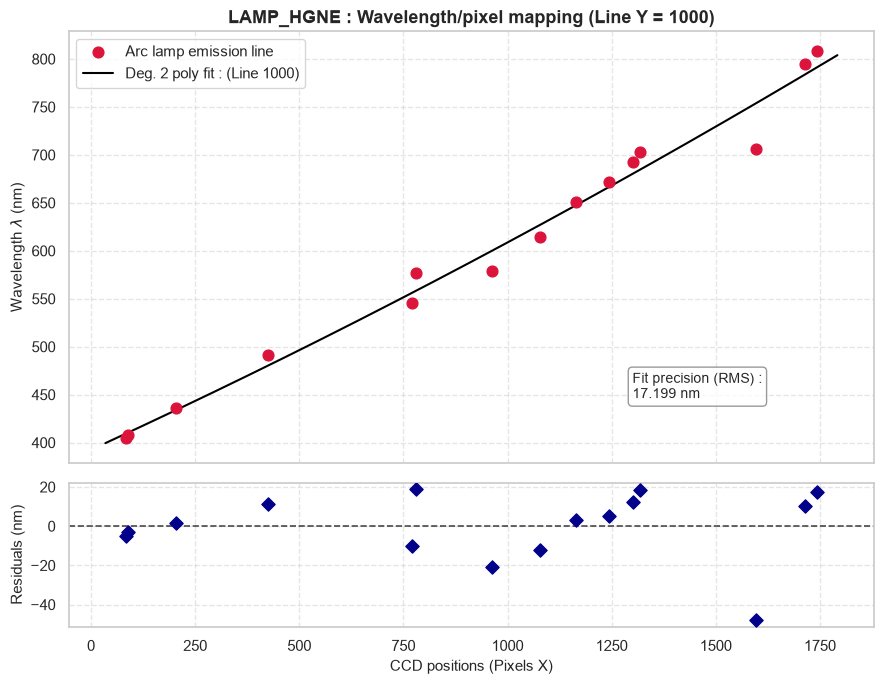

In [57]:
def plot_calib_ligne(ligne_choisie, fits_sorted, calib_matrix, true_wavelengths, degre_calib):
    valid_tids = list(fits_sorted.keys())
    x_mesure = np.array([
        np.polyval(fits_sorted[tid][0], ligne_choisie) for tid in valid_tids
    ])

    coeffs_calib_ligne = calib_matrix[ligne_choisie]
    x_fit_continu = np.linspace(x_mesure.min() - 50, x_mesure.max() + 50, 1000)
    wl_fit_continu = np.polyval(coeffs_calib_ligne, x_fit_continu)

    wl_predit = np.polyval(coeffs_calib_ligne, x_mesure)
    residus = true_wavelengths - wl_predit
    rms = np.sqrt(np.mean(residus**2))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    ax1.scatter(x_mesure, true_wavelengths, color='crimson', marker='o', s=60,
                label='Arc lamp emission line', zorder=3)
    ax1.plot(x_fit_continu, wl_fit_continu, color='black', lw=1.5,
             label=f'Deg. {degre_calib} poly fit : (Line {ligne_choisie})')
    ax1.set_ylabel(r"Wavelength $\lambda$ (nm)", fontsize=11)
    ax1.set_title(f"{OBJECT_NAME} : Wavelength/pixel mapping (Line Y = {ligne_choisie})",
                  fontsize=13, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')

    text_perf = f"Fit precision (RMS) :\n{rms:.3f} nm"
    ax1.text(0.70, 0.15, text_perf, transform=ax1.transAxes, fontsize=10,
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    ax2.scatter(x_mesure, residus, color='darkblue', marker='D', s=45, zorder=3)
    ax2.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
    ax2.set_xlabel("CCD positions (Pixels X)", fontsize=11)
    ax2.set_ylabel("Residuals (nm)", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)
    # ax2.set_ylim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()


plot_calib_ligne(1000, fits_sorted, calib_matrix, true_wavelengths, degre_calib)

### 5. Continuité des coefficients de calibration le long du CCD

In [ ]:
# fig, axes = plt.subplots(degre_calib + 1, 1, figsize=(10, 2.5 * (degre_calib + 1)), sharex=True)
# lignes_Y = np.arange(0, int(MAX_H) + 1)
# noms_coefs = [f"Coefficient (ordre {degre_calib - i})" for i in range(degre_calib + 1)]

# for i in range(degre_calib + 1):
#     axes[i].plot(lignes_Y, calib_matrix[:, i], color='darkblue', lw=2)
#     axes[i].set_ylabel(noms_coefs[i], fontsize=11)
#     axes[i].grid(ls='--', alpha=0.5)

# axes[-1].set_xlabel("Lignes du détecteur (Axe Y)", fontsize=12)
# fig.suptitle("Diagnostic : Continuité des coefficients de calibration", fontsize=14, y=0.95)
# plt.tight_layout()
# plt.show()

### 6. Comparaison de la loi de dispersion à plusieurs hauteurs

In [ ]:
# rows_to_check = [0, int(MAX_H) // 2, int(MAX_H)]
# x_fine = np.linspace(0, MAX_W, 500)

# plt.figure(figsize=(9, 6))
# for r in rows_to_check:
#     wl_fine = np.polyval(calib_matrix[r], x_fine)
#     plt.plot(x_fine, wl_fine, lw=2, label=f"Ligne Y = {r}")

# plt.xlabel("Position du pixel en X", fontsize=12)
# plt.ylabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
# plt.title("Évolution de la loi de dispersion à différentes hauteurs du CCD", fontsize=13)
# plt.legend()
# plt.grid(ls='--', alpha=0.5)
# plt.show()

### 7. Spectre scientifique calibré

In [ ]:
y_choisi = 600
flux_ligne = MASTER_SCIENCE_UNCORR[y_choisi, :][::-1]
lambdas_ligne = np.polyval(calib_matrix[y_choisi], np.arange(MAX_W))  # <- la vraie carte calibrée

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(lambdas_ligne, flux_ligne, color='indigo', lw=1.5, alpha=0.7,
         label=f'Ligne Y = {y_choisi}')
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Spectre scientifique calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# sauvegarde de la courbe de longueur d'onde pour la ligne choisie en FITS
from astropy.io import fits # Redéfinit 'fits' comme étant le module
data = (lambdas_ligne)
filename = f"{OBJECT_NAME}_TEST2_lambda_ligne_{y_choisi}.fits"
hdu = fits.PrimaryHDU(data.astype(np.float32))
hdu.header['YLINE'] = (int(y_choisi), 'Detector line used to compute this array')
hdu.header['BUNIT'] = ('nm', 'Wavelength unit')
hdu.header['COMMENT'] = "Wavelength solution for one CCD row"
hdu.writeto(filename, overwrite=True)

print(f"Saved: {filename}")

### 8. Zoom sur une zone spectrale

In [ ]:
LAMBDA_MIN, LAMBDA_MAX = 550, 800
masque_zone = (lambdas_ligne >= LAMBDA_MIN) & (lambdas_ligne <= LAMBDA_MAX)

plt.figure(figsize=(12, 5), dpi=100)
plt.plot(lambdas_ligne[masque_zone], flux_ligne[masque_zone],
         color='crimson', lw=1, label=f'Zone {LAMBDA_MIN}-{LAMBDA_MAX} nm',marker='.',ms='3')
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Zoom sur le spectre calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.axvline(435.82)
# plt.axvline(435.6)

plt.legend()
plt.show()

## **9. Test FWHM**

In [ ]:
# Construire un tableau (row, x, fwhm) pour TOUS les points de TOUTES les raies
rows_all, x_all, fwhm_all = [], [], []

df_fwhm = df_tracks[df_tracks['fit_success']].copy()
df_fwhm = df_fwhm[np.isfinite(df_fwhm['sigma']) & np.isfinite(df_fwhm['mu'])]

rows_all = df_fwhm['row'].to_numpy()
x_all = df_fwhm['mu'].to_numpy()
fwhm_all = 2 * np.sqrt(2 * np.log(2)) * df_fwhm['sigma'].to_numpy()

# Carte 2D : scatter coloré par FWHM (équivalent de ta cellule 42 mais pour la résolution)
fig, ax = plt.subplots(figsize=(10,7))
sc = ax.scatter(
    x_all,
    rows_all,
    c=fwhm_all,
    cmap='inferno',
    s=8,
    vmin=np.percentile(fwhm_all, 2),
    vmax=np.percentile(fwhm_all, 98),
)
fig.colorbar(sc, label='FWHM (pixels)')
ax.set_xlabel('Position X (pixels)')
ax.set_ylabel('Position Y (row)')
ax.set_title('Carte 2D de la résolution instrumentale (FWHM)')
plt.show()

---

---

### SNR Plot

-----

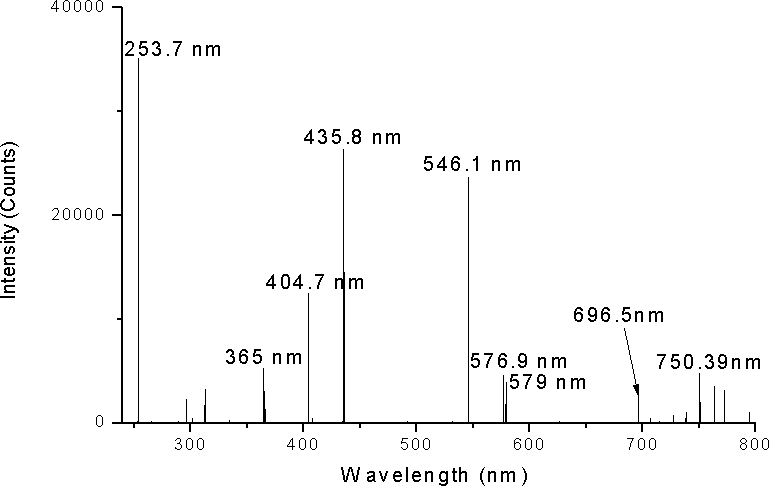

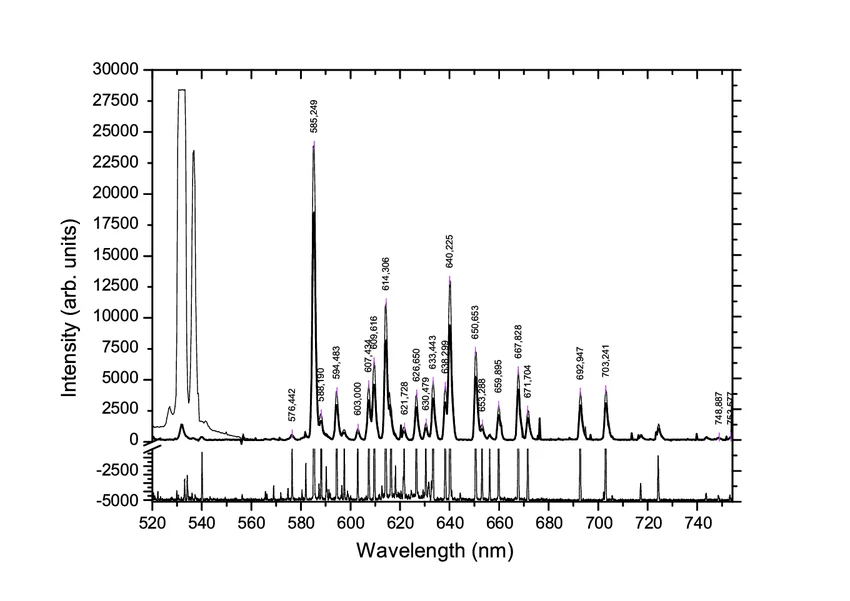

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red